In [1]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 29.5 MB/s eta 0:00:00


In [2]:
import mne
from mne.datasets.eyelink import data_path
from mne.preprocessing.eyetracking import read_eyelink_calibration
from mne.viz.eyetracking import plot_gaze

et_fpath = data_path() / "eeg-et" / "sub-01_task-plr_eyetrack.asc"
eeg_fpath = data_path() / "eeg-et" / "sub-01_task-plr_eeg.mff"

raw_et = mne.io.read_raw_eyelink(et_fpath, create_annotations=["blinks"])
raw_eeg = mne.io.read_raw_egi(eeg_fpath, events_as_annotations=True).load_data()
raw_eeg.filter(1, 30)

Using default location ~/mne_data for eyelink...
Creating /root/mne_data


  0%|                                               | 0.00/112M [00:00<?, ?B/s]

Unzipping contents of '/root/mne_data/MNE-eyelink-data.zip' to '/root/mne_data'


Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 13s (107.0 MB)
Loading /root/mne_data/MNE-eyelink-data/eeg-et/sub-01_task-plr_eyetrack.asc


/tmp/ipykernel_1004/2271825229.py:6: RuntimeWarning: Setting non-standard config type: "MNE_DATASETS_EYELINK_PATH"
  et_fpath = data_path() / "eeg-et" / "sub-01_task-plr_eyetrack.asc"


Pixel coordinate data detected.Pass `scalings=dict(eyegaze=1e3)` when using plot method to make traces more legible.
Pupil-size area detected.
Found 64 button event(s) in this file.
No button events found in this file.
There are 2 recording blocks in this file. Times between blocks will be annotated with BAD_ACQ_SKIP.
Reading EGI MFF Header from /root/mne_data/MNE-eyelink-data/eeg-et/sub-01_task-plr_eeg.mff...
    Reading events ...
    Assembling measurement info ...
    Excluding events {} ...
Reading 0 ... 190020  =      0.000 ...   190.020 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 30.0

<RawMff | signal1.bin, 134 x 190021 (190.0 s), ~194.4 MiB, data loaded>

In [3]:
mne.preprocessing.eyetracking.interpolate_blinks(
  raw_et, buffer=(0.05, 0.2), interpolate_gaze=True
)

et_events = mne.find_events(raw_et, min_duration=0.01, shortest_event=1, uint_cast=True)
eeg_events = mne.find_events(raw_eeg, stim_channel="DIN3")

event_dict = dict(Flash=2)

Interpolating missing data during blinks...
Interpolated 3 channels: ['xpos_right', 'ypos_right', 'pupil_right']
Removing 'BAD_' from BAD_blink.
Finding events on: DIN
16 events found on stim channel DIN
Event IDs: [2]
Finding events on: DIN3
16 events found on stim channel DIN3
Event IDs: [1]


In [4]:
import numpy as np
eeg_blinks = np.array([0.492, 46.731, 49.373, 49.397, 49.398, 57.091, 57.113, 57.115, 65.407,
  65.429, 65.431, 73.923, 73.945, 73.947, 81.84, 81.862, 81.864, 89.956,
  89.977, 89.98, 97.772, 97.794, 97.796, 106.187, 106.211, 106.213, 106.731,
 114.403, 114.426, 114.428, 122.42, 122.443, 122.445, 130.137, 130.16, 130.161,
 138.453, 138.476, 138.478, 146.97, 146.992, 146.994, 154.886, 154.909, 154.91,
 163.001, 163.024, 163.026, 166.729, 170.818, 170.841, 170.843])
print(eeg_blinks)
print(eeg_events) #computer flash

[  0.492  46.731  49.373  49.397  49.398  57.091  57.113  57.115  65.407
  65.429  65.431  73.923  73.945  73.947  81.84   81.862  81.864  89.956
  89.977  89.98   97.772  97.794  97.796 106.187 106.211 106.213 106.731
 114.403 114.426 114.428 122.42  122.443 122.445 130.137 130.16  130.161
 138.453 138.476 138.478 146.97  146.992 146.994 154.886 154.909 154.91
 163.001 163.024 163.026 166.729 170.818 170.841 170.843]
[[ 49397      0      1]
 [ 57113      0      1]
 [ 65429      0      1]
 [ 73945      0      1]
 [ 81862      0      1]
 [ 89977      0      1]
 [ 97794      0      1]
 [106211      0      1]
 [114426      0      1]
 [122443      0      1]
 [130160      0      1]
 [138476      0      1]
 [146992      0      1]
 [154909      0      1]
 [163024      0      1]
 [170841      0      1]]


In [5]:
import numpy as np
import mne

#Limit to 120 seconds
raw_eeg_175 = raw_eeg.copy().crop(tmin=0, tmax=175)

#Pick only channels E1, E2, E3
raw_eeg_175 = raw_eeg_175.pick_channels(['E1', 'E2', 'E3'])

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


# thay cách clean ở ô này thôi

In [6]:
from mne.preprocessing import ICA, regress_artifact

raw_eeg_175.set_channel_types({'E1': 'eog'})

raw_eeg_175.set_eeg_reference(projection=True)
clean_reg, _ = regress_artifact(raw_eeg_175, picks='eeg')

ica = ICA(n_components=2, random_state=97)
ica.fit(clean_reg)

ica.exclude = [0, 2]

clean_eeg_175 = ica.apply(clean_reg.copy())



EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
Fitting ICA to data using 2 channels (please be patient, this may take a while)
    Applying projection operator with 1 vector (pre-whitener computation)
    Applying projection operator with 1 vector (pre-whitener application)
Selecting by number: 2 components
    Applying projection operator with 1 vector (pre-whitener application)
Fitting ICA took 1.1s.
Applying ICA to Raw instance
    Applying projection operator with 1 vector (pre-whitener application)
    Transforming to ICA space (2 components)
    Zeroing out 1 ICA component
    Projecting back using 2 PCA components


/tmp/ipykernel_1004/3599125398.py:9: RuntimeWarning: Using n_components=2 (resulting in n_components_=2) may lead to an unstable mixing matrix estimation because the ratio between the largest (2) and smallest (1.8e-32) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 1
  ica.fit(clean_reg)


In [7]:
#Parameters
win_len = 2.0
overlap = 0.5
step = win_len - overlap

sfreq = clean_eeg_175.info['sfreq']   #sampling frequency
n_samples = clean_eeg_175.n_times
duration = n_samples / sfreq

#Create window start times
win_starts = np.arange(0, duration - win_len + step, step)

windows = []
labels = []

for start in win_starts:
  end = start + win_len
  # Extract the window data
  if end <= 175:
    win_data = clean_eeg_175.copy().crop(tmin=start, tmax=end)
    windows.append(win_data)
  else:
    end = 175
    win_data = clean_eeg_175.copy().crop(tmin=start, tmax=end)
    windows.append(win_data)

  # Check if any blink timestamp falls inside this window
  if np.any((eeg_blinks >= start) & (eeg_blinks < end)):
    labels.append("blink")
  else:
    labels.append("normal")

In [8]:
windows.pop()
labels.pop()
print('windows len =', len(windows))
print('labels len =', len(labels))

windows len = 116
labels len = 116


In [9]:
import numpy as np

#Extract data from each window
X_list = [w.get_data() for w in windows]

#Check that all windows have the same shape
shapes = [x.shape for x in X_list]
print(set(shapes))

#Stack into a 3D array: (n_windows, n_channels, n_samples)
X = np.stack(X_list, axis=0)

#Flatten into 2D for SVM: (n_windows, n_channels*n_samples)
X = X.reshape(len(X), -1)

#Encode labels
from sklearn.preprocessing import LabelEncoder
y = LabelEncoder().fit_transform(labels)

#Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42, stratify=y
)


{(3, 2001)}


In [10]:
#SVM pipeline
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm = make_pipeline(StandardScaler(), SVC(kernel='linear', C=1))
svm.fit(X_train, y_train)

print("Test accuracy:", svm.score(X_test, y_test))

Test accuracy: 0.7083333333333334


In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Predict on the test set
y_pred = svm.predict(X_test)

#Precision, recall, F1
precision = precision_score(y_test, y_pred, average='binary')  # use 'binary' since you have 2 classes
recall = recall_score(y_test, y_pred, average='binary')
f1 = f1_score(y_test, y_pred, average='binary')

print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1-score:  {f1:.2f}")

Precision: 0.76
Recall:    0.89
F1-score:  0.82


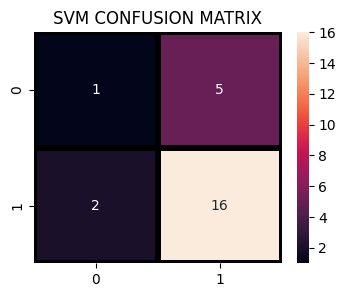

In [12]:
#SVM Confusion Matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
y_pred_svm = svm.predict(X_test)
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt="d", linecolor="k", linewidths=3)
plt.title("SVM CONFUSION MATRIX")
plt.show()

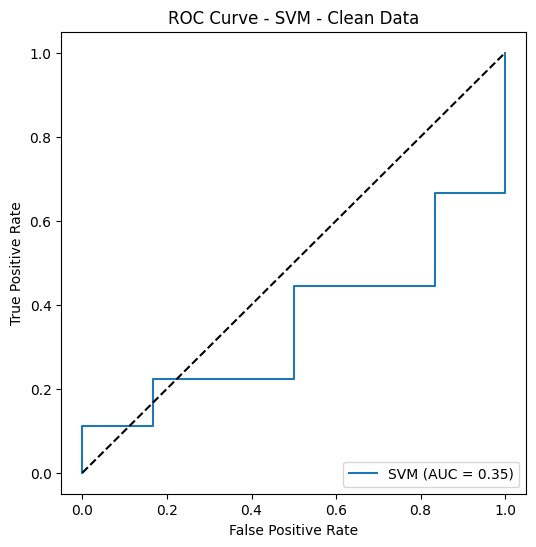

In [13]:
#ROC SVM
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
svm = make_pipeline(StandardScaler(), SVC(kernel='linear', C=1, probability=True))
svm.fit(X_train, y_train)

y_prob_svm = svm.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_svm)
auc = roc_auc_score(y_test, y_prob_svm)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"SVM (AUC = {auc:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM - Clean Data")
plt.legend(loc="lower right")
plt.show()

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

#Decision Tree pipeline
dt = make_pipeline(
  StandardScaler(),
  DecisionTreeClassifier(
    criterion='gini',
    max_depth=6,
    random_state=42
  )
)

#Train
dt.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(max_depth=6, random_state=42))])

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Predict on the test set
y_pred = dt.predict(X_test)

#Precision, recall, F1
precision = precision_score(y_test, y_pred, average='binary')  # use 'binary' since you have 2 classes
recall = recall_score(y_test, y_pred, average='binary')
f1 = f1_score(y_test, y_pred, average='binary')

print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1-score:  {f1:.2f}")

Precision: 0.70
Recall:    0.78
F1-score:  0.74


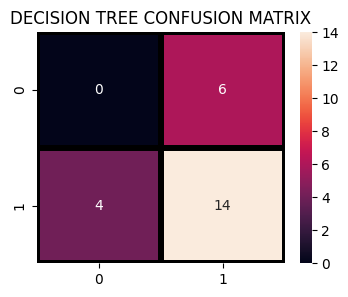

In [16]:
#Decision Tree Confusion Matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
y_pred_dt = dt.predict(X_test)
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt="d", linecolor="k", linewidths=3)
plt.title("DECISION TREE CONFUSION MATRIX")
plt.show()

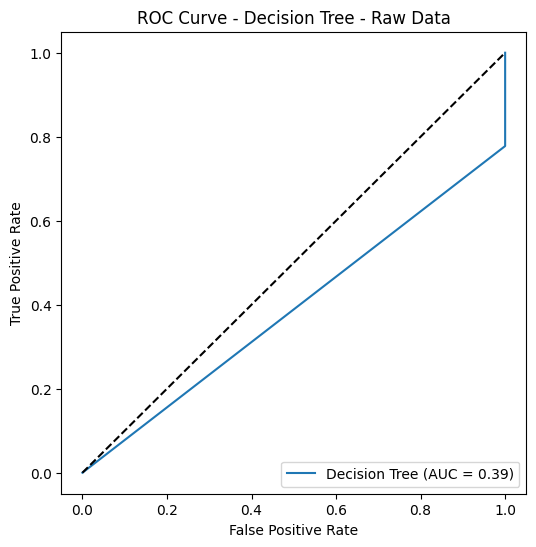

In [17]:
#Decision tree ROC
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
svm = make_pipeline(StandardScaler(), SVC(kernel='linear', C=1, probability=True))
svm.fit(X_train, y_train)

y_prob_dt = dt.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_dt)
auc = roc_auc_score(y_test, y_prob_dt)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Decision Tree (AUC = {auc:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree - Raw Data")
plt.legend(loc="lower right")
plt.show()